In [2]:
import pandas as pd

# Load the merged stock + news dataset
df = pd.read_csv('../data/merged_stock_news.csv')
df = df.rename(columns={'date': 'Date'})
df['Date'] = pd.to_datetime(df['Date'])


In [3]:
from textblob import TextBlob
df['sentiment'] = df['headline'].astype(str).apply(lambda x: TextBlob(x).sentiment.polarity)

daily_sentiment = (
    df.groupby(['stock', 'Date'])['sentiment']
    .mean()
    .reset_index()
    .rename(columns={'sentiment': 'daily_sentiment'})
)


In [4]:
# Daily return
df['daily_return'] = df.groupby('stock')['Close'].pct_change()

# Moving Average (10)
df['MA_10'] = df.groupby('stock')['Close'].transform(lambda x: x.rolling(window=10).mean())

# RSI (14)
def rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -1 * delta.clip(upper=0)
    avg_gain = gain.rolling(window=period, min_periods=period).mean()
    avg_loss = loss.rolling(window=period, min_periods=period).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

df['RSI_14'] = df.groupby('stock')['Close'].transform(lambda x: rsi(x))

# MACD
def macd(series, fast=12, slow=26, signal=9):
    exp1 = series.ewm(span=fast, adjust=False).mean()
    exp2 = series.ewm(span=slow, adjust=False).mean()
    return exp1 - exp2

df['MACD'] = df.groupby('stock')['Close'].transform(lambda x: macd(x))


In [5]:
final_data = pd.merge(
    df,
    daily_sentiment,
    on=['stock', 'Date'],
    how='left'
)


In [6]:
# Show the first few rows with new features
print(final_data[['stock', 'Date', 'Close', 'daily_return', 'MA_10', 'RSI_14', 'MACD', 'daily_sentiment']].head(15))


   stock       Date       Close  daily_return  MA_10  RSI_14      MACD  \
0   MSFT 2024-06-26  452.160004           NaN    NaN     NaN  0.000000   
1   TSLA 2024-03-07  178.649994           NaN    NaN     NaN  0.000000   
2   NVDA 2024-04-09   85.353996           NaN    NaN     NaN  0.000000   
3   AAPL 2024-06-11  207.149994           NaN    NaN     NaN  0.000000   
4   META 2024-03-11  483.589996           NaN    NaN     NaN  0.000000   
5   AMZN 2024-04-19  174.630005           NaN    NaN     NaN  0.000000   
6   META 2024-05-14  471.850006     -0.024277    NaN     NaN -0.936523   
7   META 2024-02-09  468.109985     -0.007926    NaN     NaN -1.957943   
8   TSLA 2024-04-19  147.050003     -0.176882    NaN     NaN -2.520797   
9   MSFT 2024-06-28  446.950012     -0.011522    NaN     NaN -0.415612   
10  GOOG 2024-02-05  144.929993           NaN    NaN     NaN  0.000000   
11  AMZN 2024-01-05  145.240005     -0.168299    NaN     NaN -2.344501   
12  GOOG 2024-02-08  147.220001      0

In [7]:
# Only numeric columns we care about
numeric_cols = ['daily_return', 'MA_10', 'RSI_14', 'MACD', 'daily_sentiment']
correlation_matrix = final_data[numeric_cols].corr(method='pearson')

print("Correlation Matrix:")
print(correlation_matrix)


Correlation Matrix:
                 daily_return     MA_10    RSI_14      MACD  daily_sentiment
daily_return         1.000000 -0.037868  0.511453  0.065976         0.033074
MA_10               -0.037868  1.000000 -0.059419 -0.573607        -0.057748
RSI_14               0.511453 -0.059419  1.000000  0.359123        -0.020163
MACD                 0.065976 -0.573607  0.359123  1.000000        -0.015169
daily_sentiment      0.033074 -0.057748 -0.020163 -0.015169         1.000000


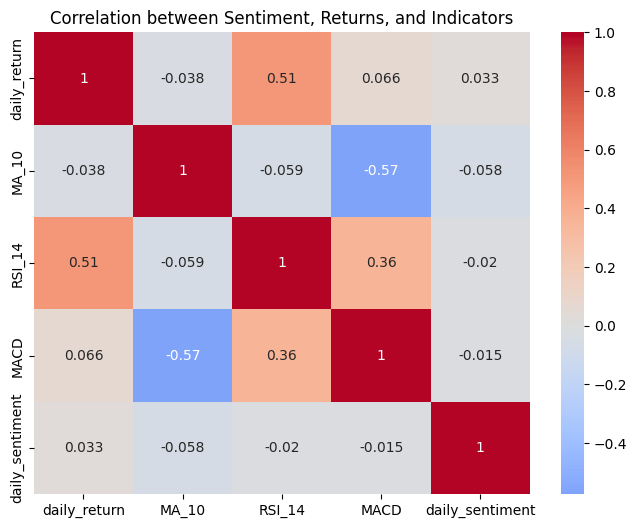

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation between Sentiment, Returns, and Indicators')
plt.show()


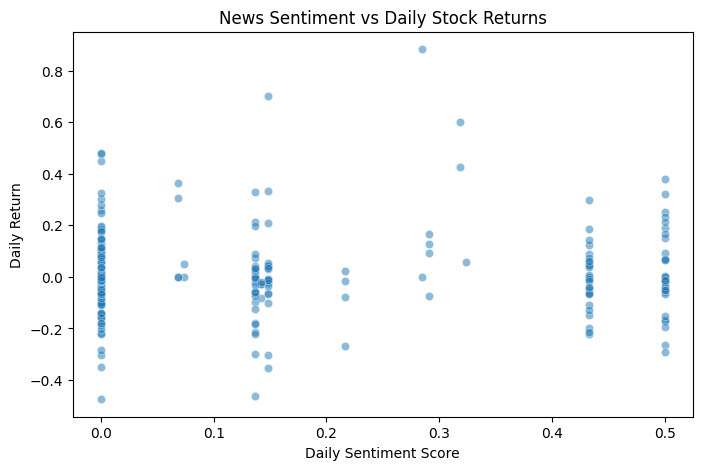

In [9]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=final_data, x='daily_sentiment', y='daily_return', alpha=0.5)
plt.title('News Sentiment vs Daily Stock Returns')
plt.xlabel('Daily Sentiment Score')
plt.ylabel('Daily Return')
plt.show()
